# Coursework Set Week 6

**Common remarks**:

* Deadline: Sunday at 23:59h for the week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: L.B.J.SUBERBERE
* Username: lbjsuberbere
* Student number: s6080081
* Group (AS1, etc.): AS2

-----

In [1]:
totalpoints = currentpoints = 0

### Exploring a HI data cube (7 pt) <font color='red'><b>COURSEWORK</b></font>
   
* Download FITS image [ngc6946.fits](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/ngc6946.fits)
* Create a mosaic with 5 rows and 10 columns of channel maps for the Z indices ``range(1, 101, 2)``
* Remove axis labeling with Axes methods ``set_xticklabels([])`` and ``set_yticklabels([])``.
* If you add two channel maps you get a new map where each pixel is the sum of the two maps. If you add all channel maps (not the noisy ones), you get a so called *total HI* map.

    * Select a suitable range of channel maps and sum them to get a total HI map. Make a plot of this map
    * Label the axes with the header values of ``CTYPE1`` and ``CTYPE2``.
    * Make a locatable colorbar and label its Y axis with the header value of ``BUNIT``. 
        
* A *position velocity* (PV) map is a slice through the data at one fixed spatial position. 
   It tells you something about how the velocities in a galaxy behave as function of position 
   and one fixed position.   
   In NumPy jargon a PV map can be an YZ slice or a XZ slice. 

    * Plot a PV map for a fixed Right Ascension (R.A.) with index 50.
    * Plot a vertical line at Dec. with index 40.
    * Label the axes with the header values of ``CTYPE2`` and ``CTYPE3``. <br>&nbsp;</br>
        
* A *global HI spectral profile* is a slice in along the spectral axis at a fixed Right Ascension and Declination.
   It is a 1D curve with intensities as function of frequency (or velocity). It shows you at which 
   velocity most of the gas is rotating in a galaxy given a position in R.A. and Dec.

    * Plot a global profile at R.A. with index 50 and Dec. with index 40.
    * Label the plot axes with the header values of ``CTYPE3`` and ``BUNIT``. <br>&nbsp;</br>

* What is the relation between this profile and the vertical line in the previous plot of the PV diagram?   

**Answers**:

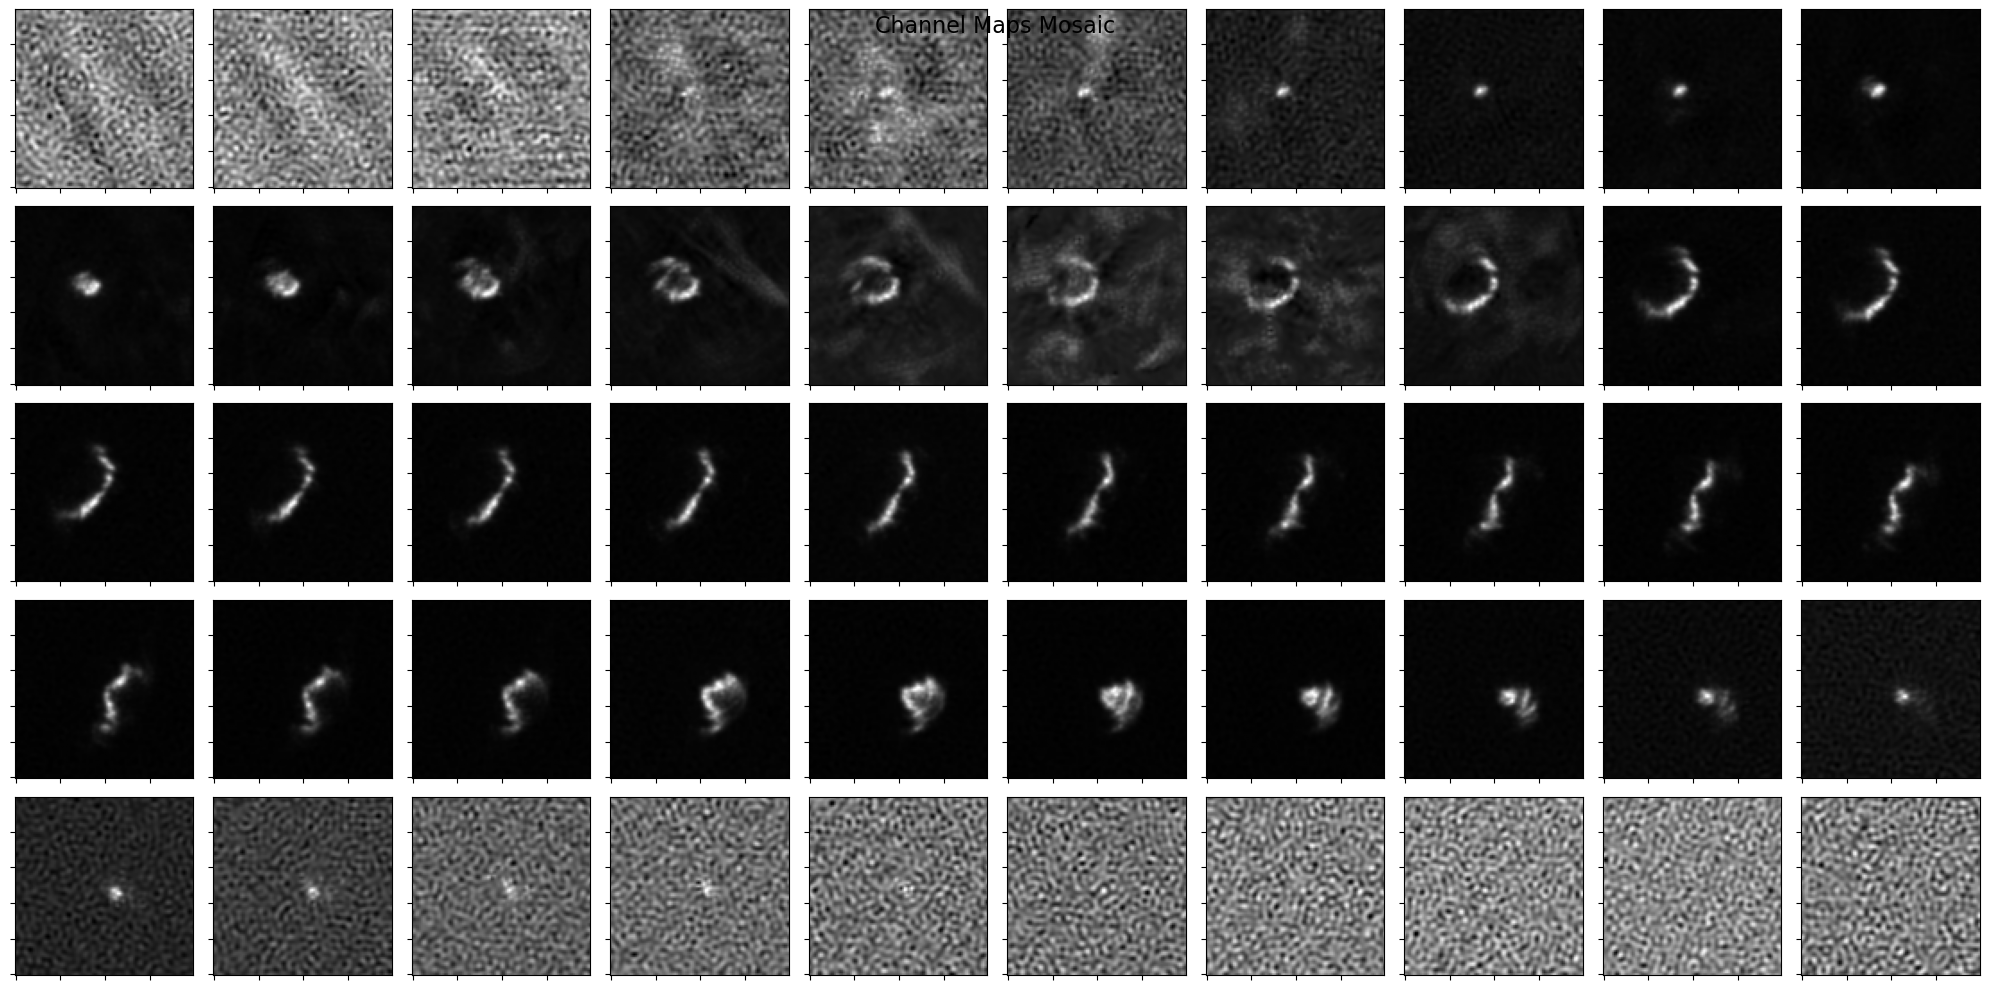

Text(0.5, 1.0, 'Global HI Spectrum at R.A.= 50, Dec.= 40')

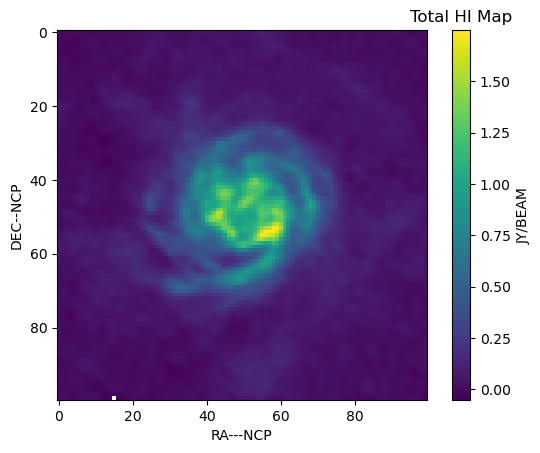

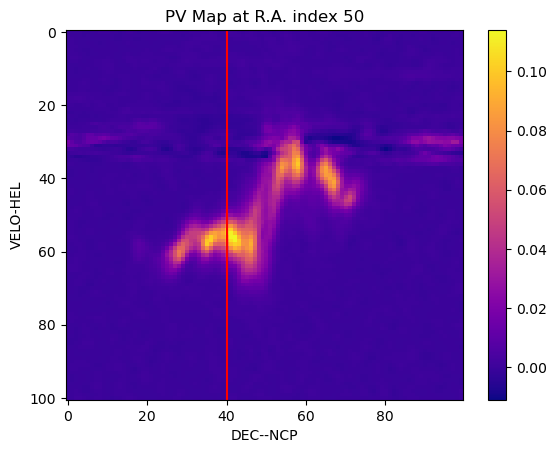

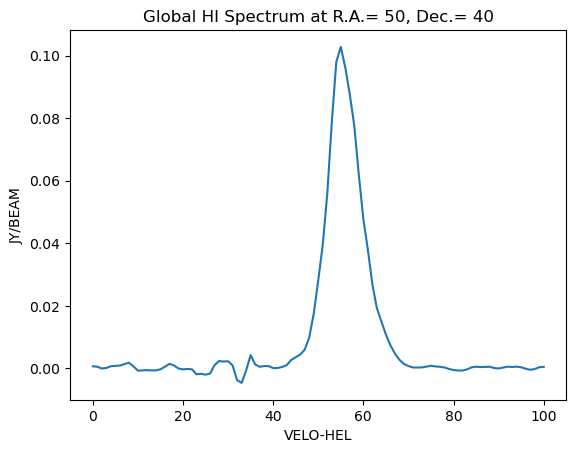

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from mpl_toolkits.axes_grid1 import make_axes_locatable

#Load the FITS data
hdul = fits.open('ngc6946.fits')  
dat = hdul[0].data  
header = hdul[0].header

# 2. Mosaic of channel maps
fig, axes = plt.subplots(5, 10, figsize=(20, 10))
axes = axes.flatten()

for i, z in enumerate(range(1, 101, 2)):
    if i >= len(axes):
        break
    ax = axes[i]
    im = ax.imshow(dat[z, :, :], origin='lower', cmap='gray')
    ax.set_xticklabels([])
    ax.set_yticklabels([])

plt.tight_layout()
plt.suptitle("Channel Maps Mosaic", fontsize=16)
plt.show()

#Total HI map
total_HI = np.sum(dat[20:80, :, :], axis=0)

fig, ax = plt.subplots()
im = ax.imshow(total_HI, cmap='viridis')
ax.set_xlabel(header.get('CTYPE1', 'X'))
ax.set_ylabel(header.get('CTYPE2', 'Y'))

# Locatable colorbar
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.25)
cbar = plt.colorbar(im, cax=cax, label = header.get('BUNIT', 'Intensity') )
plt.title("Total HI Map")

#Position-Velocity (PV) map
pv_map = dat[:, :, 50]

fig, ax = plt.subplots()
im = ax.imshow(pv_map, aspect='auto', cmap='plasma')
ax.axvline(x=40, color='red')
ax.set_xlabel(header.get('CTYPE2', 'Dec'))
ax.set_ylabel(header.get('CTYPE3', 'Velocity'))
plt.colorbar(im, ax=ax)
plt.title(f"PV Map at R.A. index 50")

#global HI spectral profile
spectrum = dat[:, 40, 50]

fig, ax = plt.subplots()
ax.plot(spectrum)
ax.set_xlabel(header.get('CTYPE3', 'Velocity'))
ax.set_ylabel(header.get('BUNIT', 'Intensity'))
ax.set_title(f"Global HI Spectrum at R.A.= 50, Dec.= 40")

The global HI profile at RA=50, Dec=40 is the same as the values along the vertical line at Dec=40 in the PV diagram. The PV diagram shows how velocity changes with position, and the vertical line picks out the spectrum at that specific position.

<div class='alert alert-warning'>
    <b>Feedback</b> <br>

All plots needs to be Object-Oriented programmed! <b>[1pt deducted from total grade.]</b>

All your images are incorrectly oriented! The tail of the galaxy should be on top and pointing to the left. <b>[0.5pt deducted from total grade.]</b>

Your PV map is incorrect. You plotted the incorrect index, so please look again at your slicing. What does Right Ascension represent in this case? <b>[0.5pt deducted from total grade.]</b>
</div>

In [3]:
# Leave unaltered
totalpoints += 7
currentpoints += 5

### Galaxy Colour (5 pt) <font color='red'><b>COURSEWORK</b></font>
   
Download [SDSS_DR17_galaxies.fits](https://brightspace.rug.nl/content/enforced/457626-WBAS018-05.2025-2026.1/SDSS_DR17_galaxies.fits), which contains apparent magnitude in ``u, g, r, i, z`` five SDSS broad-band filters.

* Create a Pandas DataFrame from the FITS table.
* Filter out any data with negative values.
* Calculate every combination of colours from each broad band filter, e.g. u-g, u-r, u-i, u-z, g-r, ......
* Calculate the mean and standard deviation of the each colour.
* Use Object-Oriented Plotting to create a corner plot using derived colours.
* Set the xlim and ylim to be within three standard deviation.
* Add title for each histogram with information of the mean and standard deviation of each colour in the format of $\mu\pm\sigma$
 (to one decimal place).

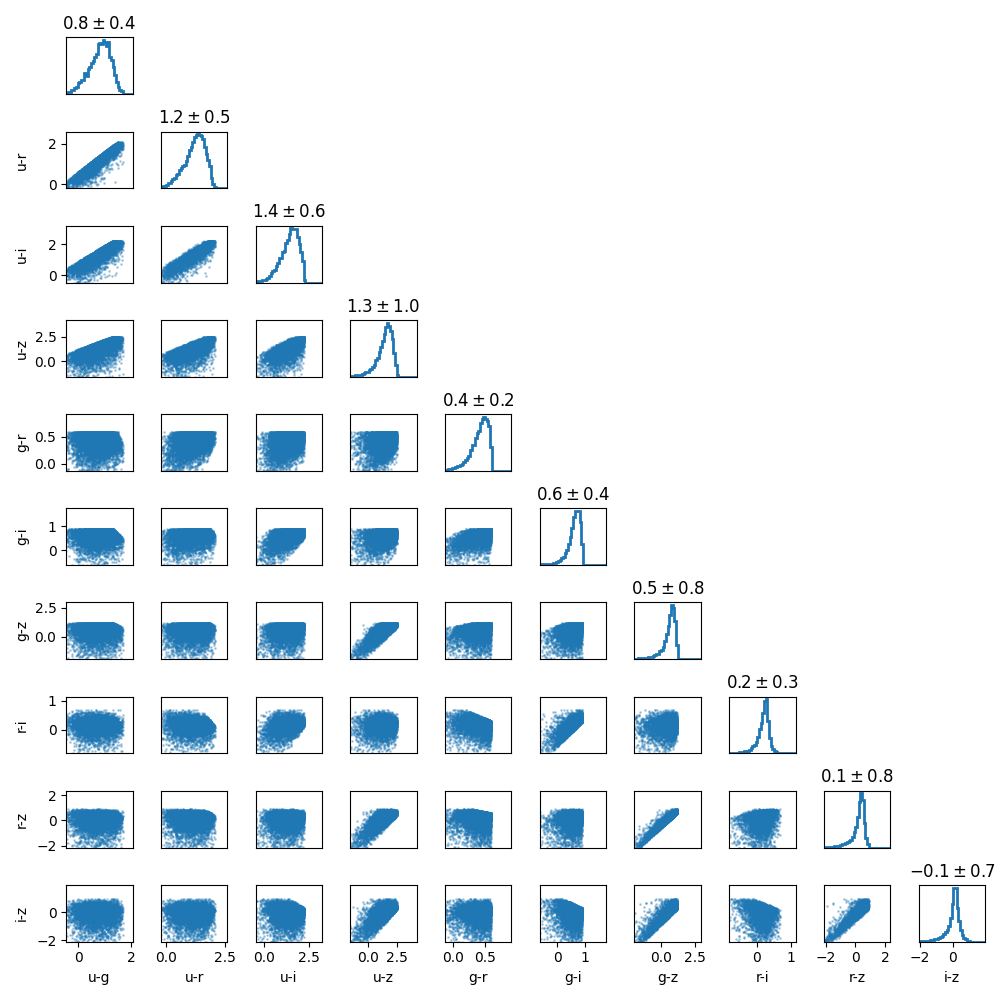
   
**Plot and answer**:

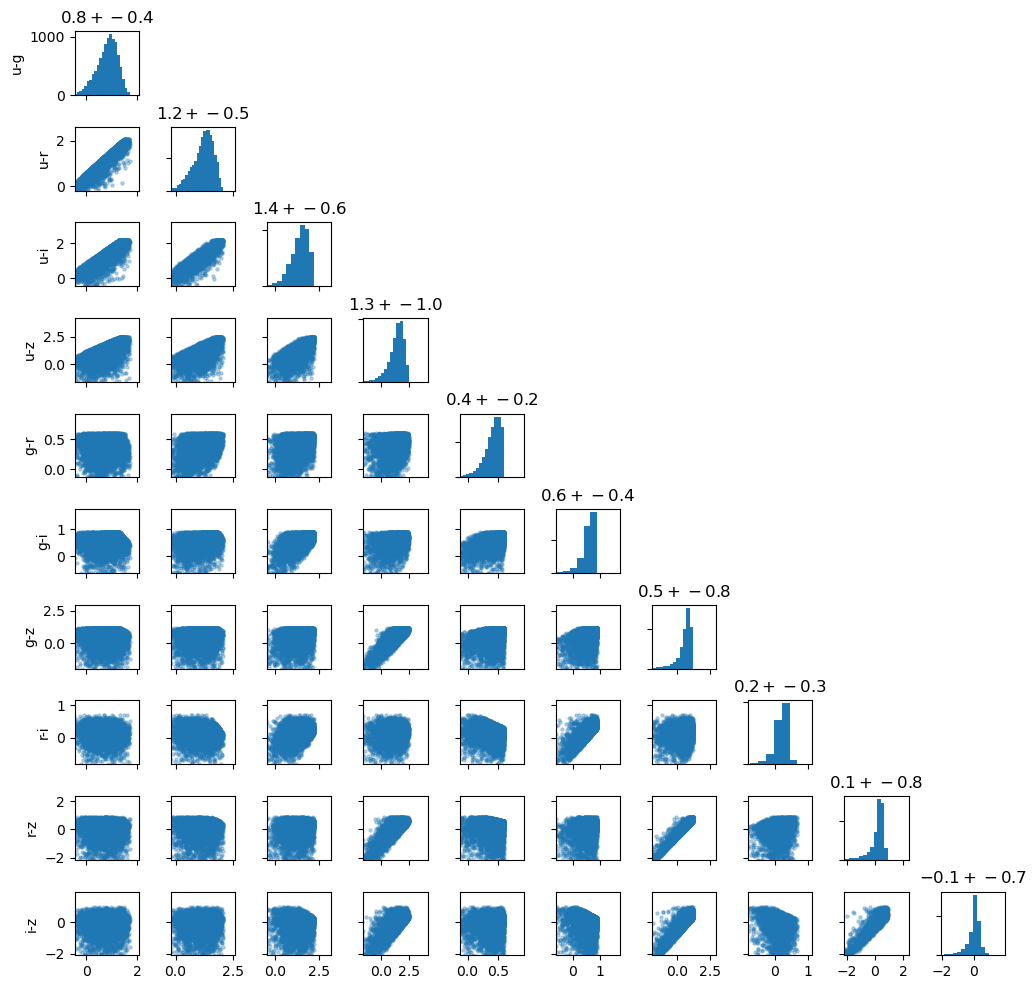

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from itertools import combinations

#Load ftis file
data = fits.open('SDSS_DR17_galaxies.fits')
df = pd.DataFrame(data[1].data)

#Filter negative magnitudes
bands = ['u', 'g', 'r', 'i', 'z']
for band in bands:
    df = df[df[band] >= 0]

#Compute all colour combinations
colours = {}
for i in range(len(bands)):
    for j in range(i + 1, len(bands)):
        colours[f"{bands[i]}-{bands[j]}"] = df[bands[i]] - df[bands[j]]
colours_df = pd.DataFrame(colours)

#Compute mean & std
colour_stats = {}

for col in colours_df.columns:
    mean = colours_df[col].mean()   # Compute mean
    std = colours_df[col].std() # Compute standard deviation
    colour_stats[col] = (mean, std) 

#Plot
fig, axes = plt.subplots(len(colours_df.columns), len(colours_df.columns), figsize=(12, 12))
plt.subplots_adjust(hspace=0.5, wspace=0.5)

for i, col1 in enumerate(colours_df.columns):
    for j, col2 in enumerate(colours_df.columns):
        ax = axes[i, j]
        mean1, std1 = colour_stats[col1]
        mean2, std2 = colour_stats[col2]

        if i == j:
            ax.hist(colours_df[col1], bins=50)
            ax.set_xlim(mean1 - 3*std1, mean1 + 3*std1)
            ax.set_title(f"${mean1:.1f} +- {std1:.1f}$")
        elif i > j:
            ax.scatter(colours_df[col2], colours_df[col1], s=5, alpha=0.3)
            ax.set_xlim(mean2 - 3*std2, mean2 + 3*std2)
            ax.set_ylim(mean1 - 3*std1, mean1 + 3*std1)
        else:
            # Upper triangle: hide axes
            ax.axis('off')

        if i < len(colours_df.columns)-1:
            ax.set_xticklabels([])
        if j > 0:
            ax.set_yticklabels([])
        if j == 0: 
            ax.set_ylabel(col1)

In [5]:
# Leave unaltered
totalpoints += 5
currentpoints += 5

### Astroquery: retrieving SDSS image and spectra (5 pt) <font color='red'><b>COURSEWORK</b></font>

Spiral galaxy M77 (NGC 1068) is a bright galaxy known for hosting an active galactic nucleus (AGN). With Astropy package, we construct M77's coordinate using the code below.

```python
from astropy import coordinates as coords

# Coordinates of M77
ra = 40.6696  # degrees
dec = -0.0133  # degrees
pos = coords.SkyCoord(ra, dec, unit="deg", frame="icrs")
```

* Use ``astroquery`` ([search regions](https://astroquery.readthedocs.io/en/latest/sdss/sdss.html#searching-regions-and-multiple-objects)) on the ``pos``, containing RA and DEC of this galaxy, to retrieve its SDSS spectrum using ``get_spectra()``. The search radius sets as ``10 arcsec`` for searching.
* The return object of ``get_spectra()`` is a list of [HDUList](https://docs.astropy.org/en/stable/io/fits/api/hdulists.html#astropy.io.fits.HDUList) objects.
* Retrieve flux and wavelengths using columns ``flux`` and ``loglam``. Note that the wavelength is in logarithmic value, you need to convert it back to a linear scale.
* The redshift of M77 is approximately ``z~0.0038``. Calculating the rest-frame wavelengths.
* Use Object-Oriented Plotting to plot:
    * a rest-frame spectrum which corrects the redshift effect (top)
    * a zoom-in spectrum at wavelength between 6450 and 6650 angstrom (bottom)
* Draw vertical lines for H$\alpha$ lines in both frames. Label them and show with legend.
* Draw vertical lines indicating approximately where the peak of the flux is, which in fact should be the H$\alpha$ line.
* An example plot is shown below.
* Calculating the velocity indicated by the difference between the two wavelengths.
* Share your thought using a markdown on what might be causing this offset. This question will not be graded, and meant to train a bit your scientific thinking. Feel free to express any thought.

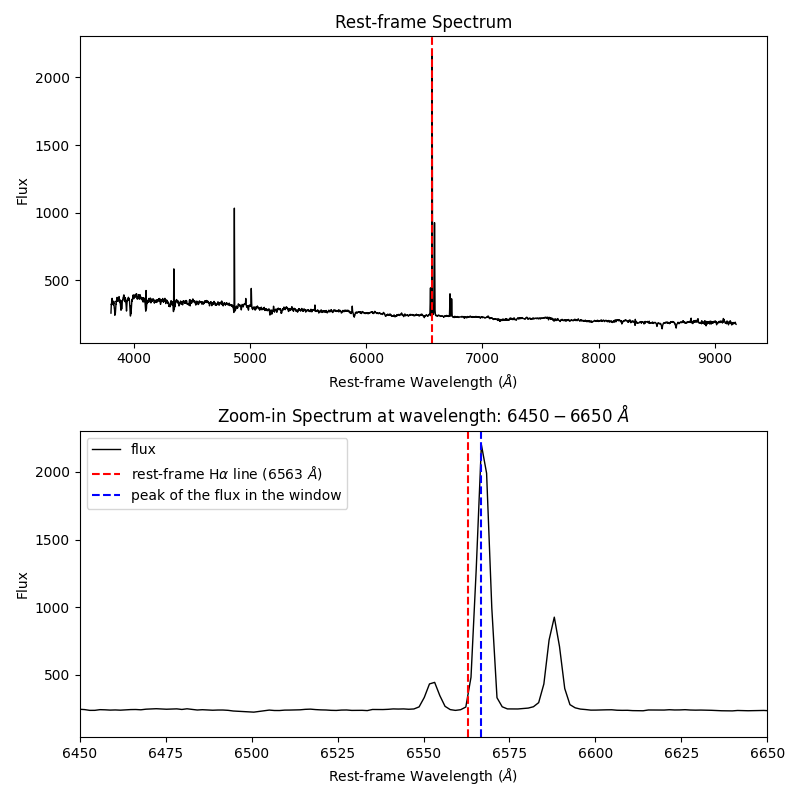

For some reason, it appears that the jupyterlab doesn't recognise the astroquery library even when i tried to install it. So the code you see here has been testes using google collab and then copy pasted here. I also provided a print after the code of what i end up getting. 

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Approximate velocity offset: 1313.6800172367778 km/s


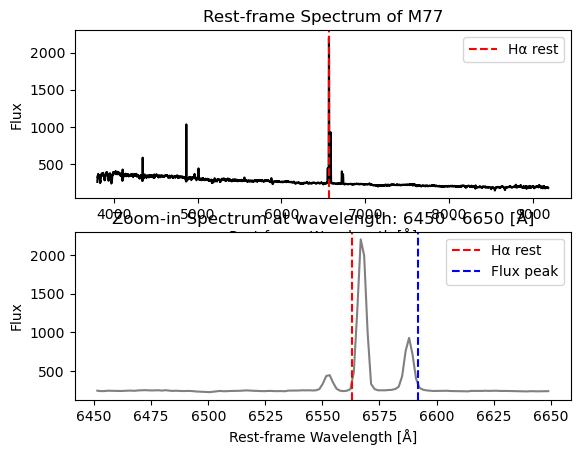

In [6]:
%pip install astroquery

from astropy import coordinates as coords
from astroquery.sdss import SDSS
from astropy import units as u
import numpy as np
import matplotlib.pyplot as plt

# Coordinates of M77
ra = 40.6696  # degrees
dec = -0.0133  # degrees
pos = coords.SkyCoord(ra, dec, unit="deg", frame="icrs")

#Query SDSS spectra within 10 arcsec
xid = SDSS.query_region(pos, radius=10*u.arcsec, spectro=True)
spec_list = SDSS.get_spectra(matches=xid)

#Extract flux and wavelength
hdu = spec_list[0][1] 
data = hdu.data
flux = data['flux']
loglam = data['loglam']
wavelength = 10**loglam

#Rest-frame correction
z = 0.0038
wavelength_rest = wavelength / (1 + z)

#Define H_alpha line
H_alpha = 6563
lines = {'Hα': H_alpha}

#Plot
fig, (ax1, ax2) = plt.subplots(2)

#Full rest-frame spectrum
ax1.plot(wavelength_rest, flux, color='black')
for name, i in lines.items():
    ax1.axvline(i, color='red', ls='--', label=f'{name} rest')
ax1.set_xlabel('Rest-frame Wavelength [Å]')
ax1.set_ylabel('Flux')
ax1.set_title('Rest-frame Spectrum of M77')
ax1.legend()

#Zoom-in around Hα
zoom_mask = (wavelength_rest > 6450) & (wavelength_rest < 6650)
ax2.plot(wavelength_rest[zoom_mask], flux[zoom_mask], color='grey')
for name, i in lines.items():
    ax2.axvline(i, color='red', ls='--', label=f'{name} rest')

# Draw approximate observed flux peak
peak_idx = np.argmax(flux[zoom_mask])
peak_wl_obs = wavelength_rest[zoom_mask][peak_idx] * (1 + z)
ax2.axvline(peak_wl_obs, color='blue', ls='--', label='Flux peak')
ax2.set_xlabel('Rest-frame Wavelength [Å]')
ax2.set_ylabel('Flux')
ax2.set_title('Zoom-in Spectrum at wavelength: 6450 - 6650 [Å]')
ax2.legend()

#Velocity calculation
c = 3e5  # km/s
delta_lambda = peak_wl_obs - H_alpha
velocity = c * delta_lambda / H_alpha
print(f"Approximate velocity offset: {velocity} km/s")

The flux peak is a little off from the Hα line at 6563 A, causing a small velocity difference. This can happen because of instrument errors, the galaxy’s rotation, or gas moving fast near the center. Small shifts like this are normal in real galaxy spectra.

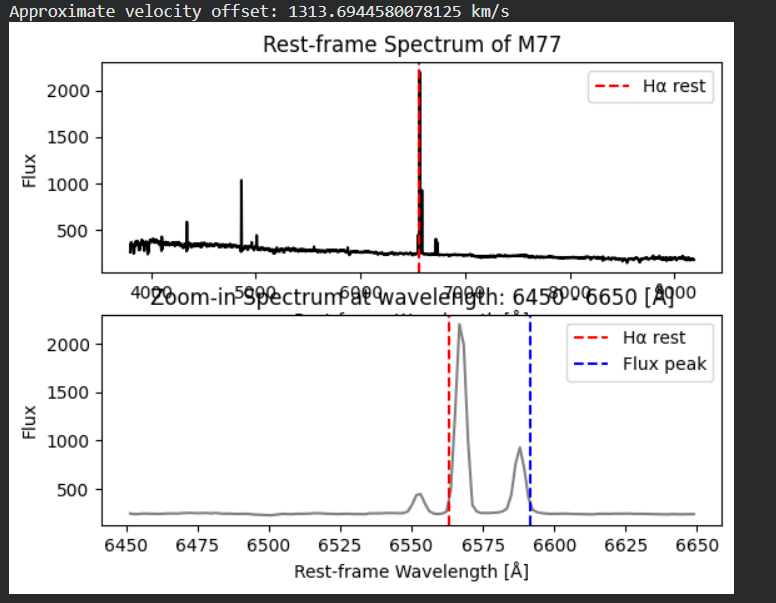

<div class='alert alert-warning'>
    <b>Feedback</b> <br>

You handed in the notebook with a not running code. You are lucky as the issue was your kernel, and I alway grade how code runs on my PC. Always check if your kernel is on Anaconda3 2024.

Your velocity calculation is incorrect. You can clearly see that your redshift line is way too off compared to the given image! <b>[0.5pt deducted from total grade.]</b>

Fix your plot. The plot is overlapping with eachother. We always expect you to hand in clear and neat plots. <b>[0.5pt deducted from total grade.]</b>

</div>

In [7]:
# Leave unaltered
totalpoints += 5
currentpoints += 4

### Comparing an image in different color scales (stretches) (4pt) <font color='red'><b>COURSEWORK</b></font>

Given is the Blaauw observatory FITS file
[20210422_Li_.00000066.FIT](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/20210422_Li_.00000066.FIT)

Use the `imdisplay()` function from the notebook *The art of plotting an image* to make a mosaic with this image using all the different scales (stretches) available to that function. 

* Add a proper docstring to the function.
* Show the used scale in the title of the plot. (hints: tight_layout, fontsize).
* Also include the image without scaling as the first plot in the mosaic.

**Answer**:

In [8]:
from astropy.visualization import ImageNormalize
from astropy.visualization import SinhStretch, AsymmetricPercentileInterval, LinearStretch,\
                                  LogStretch, PowerStretch, SqrtStretch, SquaredStretch,\
                                  HistEqStretch, ZScaleInterval
import matplotlib.pyplot as plt
from astropy.io import fits

def imdisplay(data,
              ax,
              vmin=None, vmax=None,
              percentlow=1, percenthigh=99,
              zscale=False,
              scale='linear',
              power=1.5,
              cmap='gray',
              **kwargs):
    
"""Display an image on a Matplotlib Axes with flexible scaling.

Parameters
data : array-like, image array.
ax : matplotlib.axes.Axes, axes to plot on.
vmin, vmax : float min and max values
zscale : bool
scale : str.
power : float
cmap : Colormap
**kwargs : Additional arguments.

Return
AxesImage, The plotted image."""

    if zscale:
        # Always overwrite vmin and vmax
        interval = ZScaleInterval()
        vmin, vmax = interval.get_limits(data)
    if vmin is None or vmax is None:
        interval = AsymmetricPercentileInterval(percentlow, percenthigh)
        vmin2, vmax2 = interval.get_limits(data)
        if vmin is None:
            vmin = vmin2
        if vmax is None:
            vmax = vmax2

    if scale == 'linear':
        stretch = LinearStretch(slope=0.5, intercept=0.5)
    if scale == 'sinh':
        stretch = SinhStretch()
    if scale == 'log':
        stretch = LogStretch()
    if scale == 'power':
        stretch = PowerStretch(power)
    if scale == 'sqrt':
        stretch = SqrtStretch()
    if scale == 'squared':
        stretch = SquaredStretch()
    if scale == 'hist':
        stretch = HistEqStretch(data)  # Needs argument data and data min, max for vmin, vmax
        vmin = data.min(); vmax = data.max()

    norm = ImageNormalize(vmin=vmin, vmax=vmax, stretch=stretch)
    return ax.imshow(data, interpolation='none', origin='lower', norm=norm, cmap=cmap, **kwargs)

# Open ftis and get image data
hdulist = fits.open('20210422_Li_.00000066.FIT')
image_data = hdulist[0].data
image_data = np.array(image_data, dtype=float)

scales = ['linear', 'sinh', 'log', 'power', 'sqrt', 'squared', 'hist']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, scale in zip(axes, scales):
    imdisplay(image_data, ax, scale=scale)
    ax.set_title(scale, fontsize=12)
    ax.axis('off')

IndentationError: expected an indented block after function definition on line 8 (1020511137.py, line 18)

<div class='alert alert-warning'>
    <b>Feedback</b> <br>

Code is not running! Indentation of your code is very important in Python! <b>[0.5pt deducted from total grade.]</b>

</div>

In [9]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Image stacking optical data (6pt) <font color='red'><b>COURSEWORK</b></font>

Select one of the suitable observations from the next table or
find one yourself in the
[Blaauw Observatory Overview](https://www.astro.rug.nl/intranet/sterrenwacht/files.py)

* Following the stacking procedure in the notebook about image stacking for the data you selected. Show the result.
* Align the images and repeat the stacking procedure. Show the result.
* Remove all unnecessary code and markdown text.
* Include code and result in your report.

| nr | Folder on data server |
| :---  | :---: |
| 2  | ``/net/dataserver3/data/users/sterrenwacht/images/210418/STL-6303E/i/`` |
| 3  | ``/net/dataserver3/data/users/sterrenwacht/images/190515/STL-6303E/i/`` |
| 4  | ``/net/dataserver3/data/users/sterrenwacht/images/190428/STL-6303E/i/`` |
| 5  | ``/net/dataserver3/data/users/sterrenwacht/images/190419/STL-6303E/i/`` |
| 6  | ``/net/dataserver3/data/users/sterrenwacht/images/180504/STL-6303E/i/`` |
| 7  | ``/net/dataserver3/data/users/sterrenwacht/images/160913/STL-6303E/i/`` |
| 8  | ``/net/dataserver3/data/users/sterrenwacht/images/140912/STL-6303E/i/`` |
| 9  | ``/net/dataserver3/data/users/sterrenwacht/images/131001/STL-6303E/i/`` |
| 10 | ``/net/dataserver3/data/users/sterrenwacht/images/101212/STL-6303E/i/`` |

**Code and plot**:

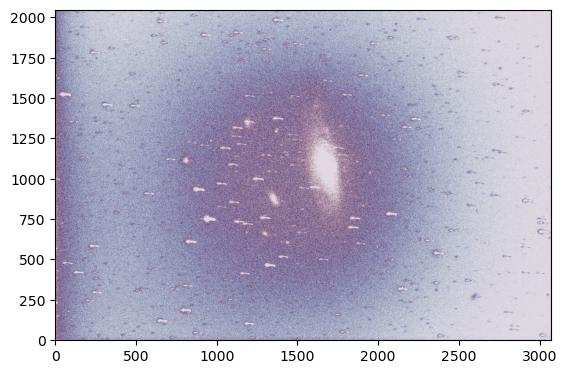

In [10]:
from astropy.io import fits
import numpy as np
from matplotlib.pyplot import subplots, show
from astropy.visualization import ImageNormalize, LinearStretch, PowerStretch, AsymmetricPercentileInterval
from scipy.ndimage import shift
from pathlib import Path

def imdisplay(data, ax, vmin=None, vmax=None, percentlow=1, percenthigh=99, scale='linear', power=1.5, cmap='gray', **kwargs):
    if vmin is None or vmax is None:
        interval = AsymmetricPercentileInterval(percentlow, percenthigh)
        vmin, vmax = interval.get_limits(data)
    if scale == 'linear':
        stretch = LinearStretch(slope=0.5, intercept=0.5)
    elif scale == 'power':
        stretch = PowerStretch(power)
    norm = ImageNormalize(vmin=vmin, vmax=vmax, stretch=stretch)
    return ax.imshow(data, origin='lower', norm=norm, cmap=cmap, **kwargs)

folder = Path("/net/dataserver3/data/users/sterrenwacht/images/131001/STL-6303E/i/")
filepaths = sorted(folder.glob("*.fits"))

images = []
for filepath in filepaths:
    hdulist = fits.open(filepath)
    images.append(hdulist[0].data.astype('float'))
    hdulist.close()

shifts = [(0,0) for _ in images]
aligned_images = [shift(img, shift=shifts[i]) for i, img in enumerate(images)]

datacube_aligned = np.stack(aligned_images)
stacked_image_aligned = np.median(datacube_aligned, axis=0)

fig, ax = subplots()
imdisplay(stacked_image_aligned, ax, percentlow=5, percenthigh=95, scale='power', power=3, cmap='twilight')
show()

<div class='alert alert-warning'>
    <b>Feedback</b> <br>

Look at the notebook in brightspace on how to align images! <b>[2.5pt deducted from total grade.]</b>

You were asked to stack your unaligned images and show the result. <b>[2.5pt deducted from total grade.]</b>

</div>

In [11]:
# Leave unaltered
totalpoints += 6
currentpoints += 1

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [12]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")

Total number of points: 27. Student score: 15.0.  Task Grade = 5.6
